# Data Evaluation: `id_to_metrics.csv`

This notebook analyses how the diffusion timestep parameters **`t_start`** and **`t_end`** (and
the auxiliary **`t_delta`**) relate to the three output quality metrics:

| Metric | Meaning | Direction |
|--------|---------|----------|
| `psnr` | Peak Signal-to-Noise Ratio | higher → better |
| `clip_similarity_target_image` | CLIP cosine similarity to target | higher → better |
| `combined_score` | Equal-weighted average of min-max–normalised PSNR and CLIP | higher → better |

The dataset has a fully balanced design: **700 samples** for every one of the
**25 (t_start, t_end) × 2 t_delta** cells (35 000 rows total).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import Normalize

METRICS_CSV = "data/id_to_metrics.csv"
METRICS     = ["psnr", "clip_similarity_target_image", "combined_score"]
METRIC_LABELS = {
    "psnr": "PSNR (dB)",
    "clip_similarity_target_image": "CLIP Similarity",
    "combined_score": "Combined Score",
}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

### 1  Load & Inspect

In [2]:
df = pd.read_csv(METRICS_CSV)

# Cast parameter columns to categorical so plots order them correctly
for col in ["t_start", "t_end", "t_delta"]:
    df[col] = pd.Categorical(df[col], categories=sorted(df[col].unique()), ordered=True)

print(f"Shape: {df.shape}")
df.describe()

Shape: (35000, 7)


,sample_id,psnr,clip_similarity_target_image,combined_score
count,3.500000e+04,35000.000000,35000.000000,35000.000000
mean,4.025714e+11,16.718012,25.954454,0.437180
std,3.248377e+11,5.682617,3.983540,0.081732
min,0.000000e+00,5.986650,7.206381,0.166650
25%,1.140000e+11,12.339049,23.366007,0.380288
50%,3.215000e+11,15.489710,26.055151,0.429726
75%,7.212500e+11,19.917516,28.581134,0.486454
max,9.240000e+11,41.063782,40.188885,0.811411


In [3]:
print("Samples per (t_start, t_end, t_delta) cell:")
df.groupby(["t_start", "t_end", "t_delta"], observed=True).size().unstack("t_delta")

Samples per (t_start, t_end, t_delta) cell:


t_delta        0.00  0.15
t_start t_end            
0.0     0.0     700   700
        0.3     700   700
        0.6     700   700
        0.9     700   700
        1.0     700   700
0.3     0.0     700   700
        0.3     700   700
        0.6     700   700
        0.9     700   700
        1.0     700   700
0.6     0.0     700   700
        0.3     700   700
        0.6     700   700
        0.9     700   700
        1.0     700   700
0.9     0.0     700   700
        0.3     700   700
        0.6     700   700
        0.9     700   700
        1.0     700   700
1.0     0.0     700   700
        0.3     700   700
        0.6     700   700
        0.9     700   700
        1.0     700   700

### 2  Metric Distributions

Before slicing by parameters, let's see the marginal distribution of each metric.

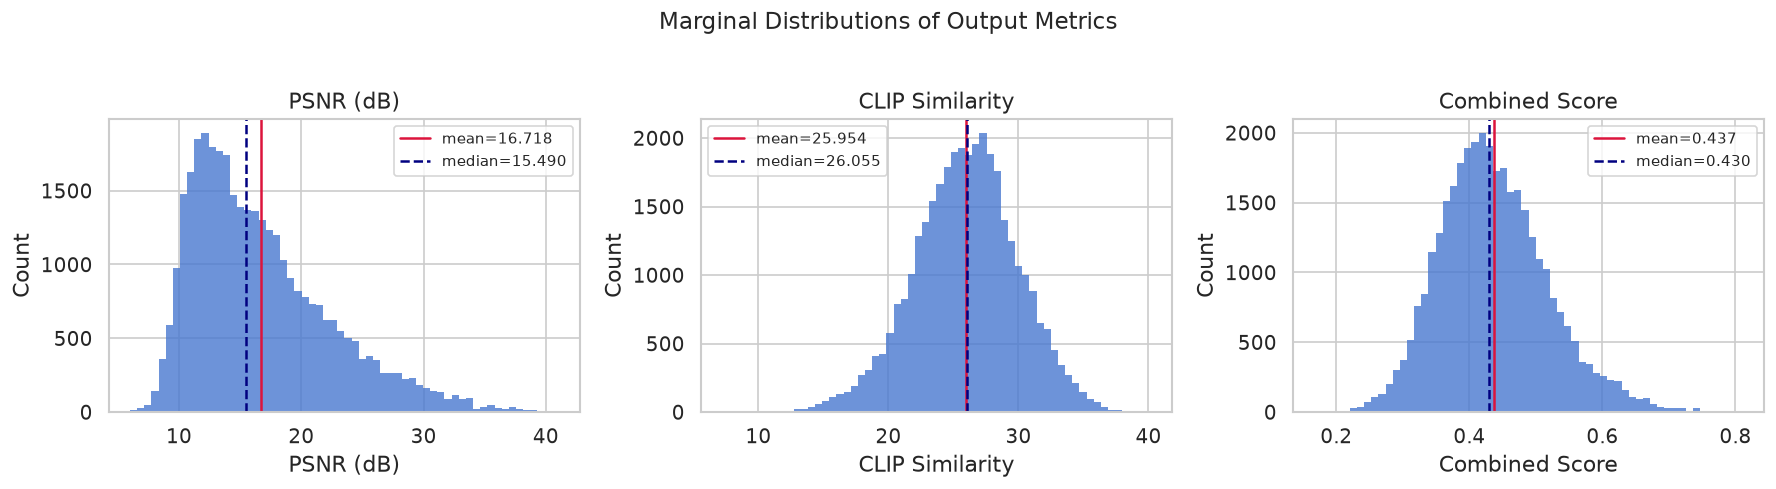

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, METRICS):
    ax.hist(df[m], bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="crimson", lw=1.5, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="navy", lw=1.5, linestyle="--", label=f"median={df[m].median():.3f}")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle("Marginal Distributions of Output Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3  Effect of `t_start` and `t_end` on Metrics

We first split the data by `t_delta` (0.0 vs 0.15) because that parameter shifts the absolute
level of every metric.  Within each `t_delta` slice we look at how the marginal means of
`t_start` and `t_end` vary.

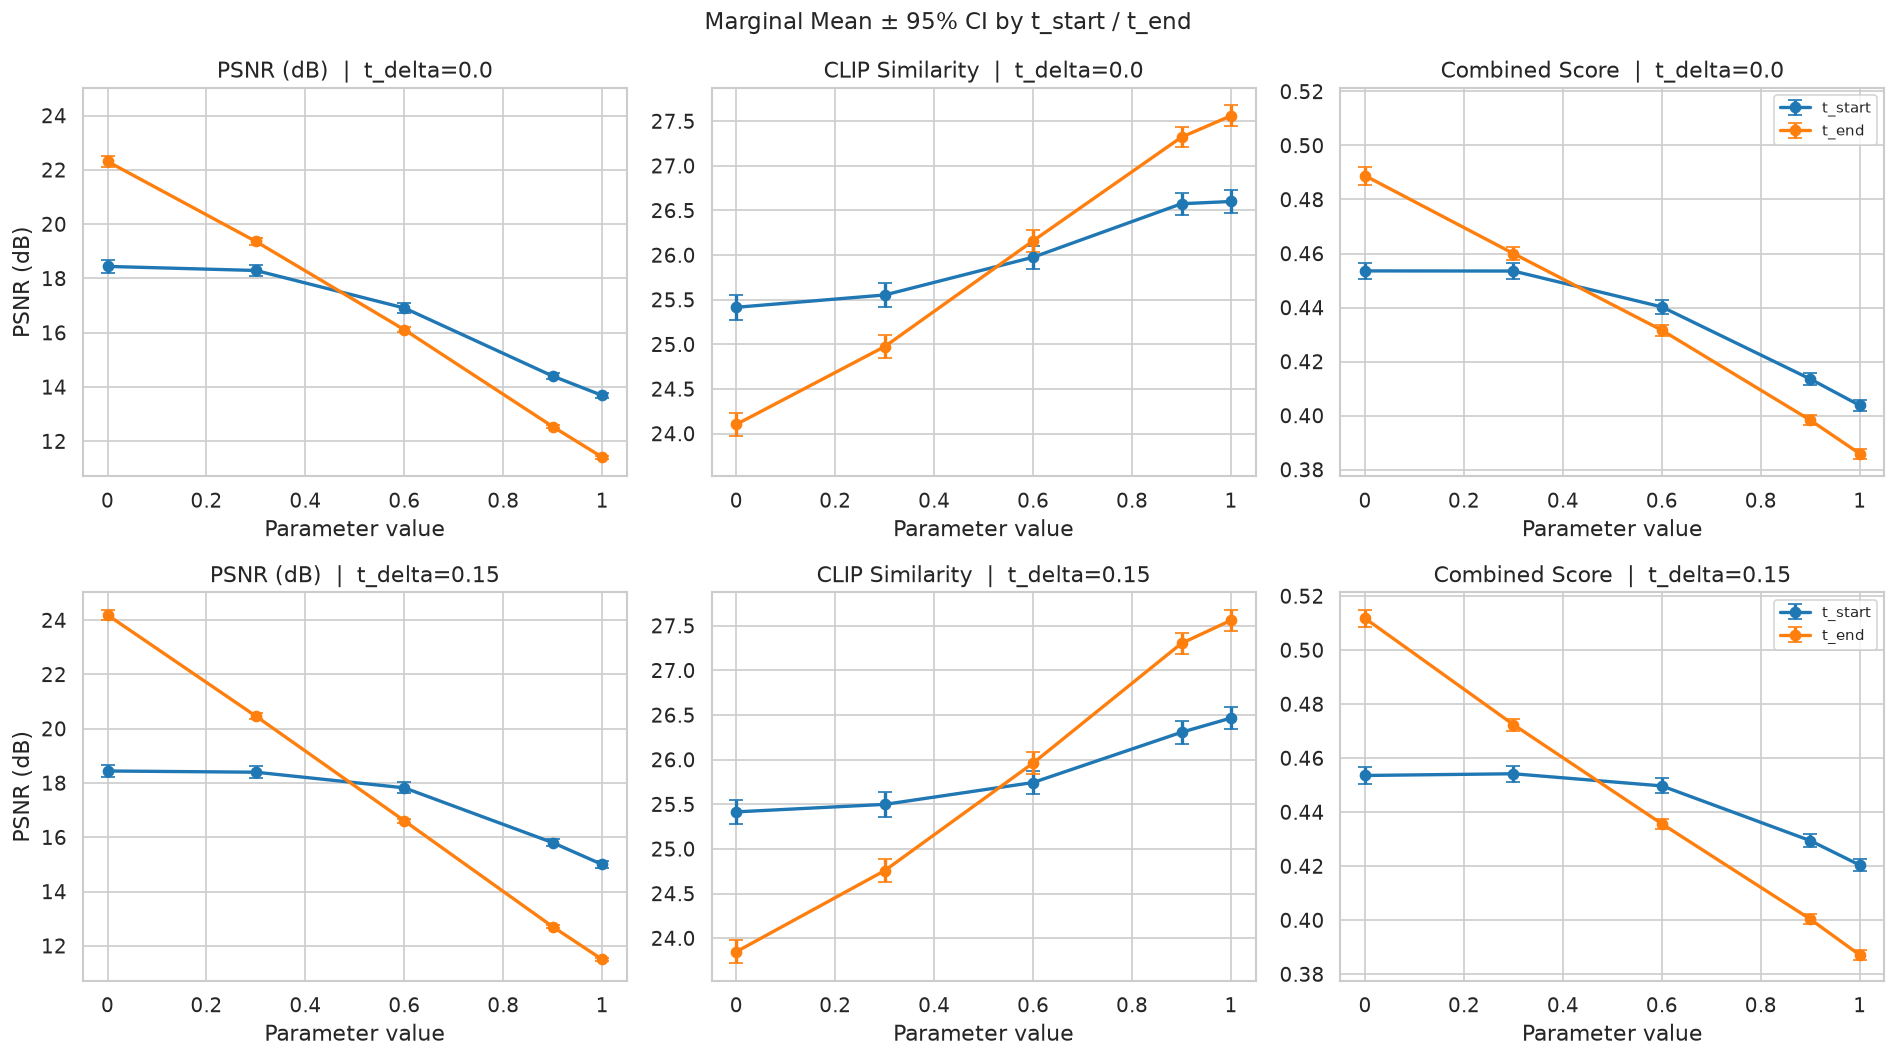

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey="col")

t_delta_vals = sorted(df["t_delta"].cat.categories)
colors = {"t_start": "#1f77b4", "t_end": "#ff7f0e"}

for row_idx, td in enumerate(t_delta_vals):
    sub = df[df["t_delta"] == td]
    for col_idx, m in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        for param, label in [("t_start", "t_start"), ("t_end", "t_end")]:
            grp = sub.groupby(param, observed=True)[m].agg(["mean", "sem"])
            x = grp.index.astype(float)
            ax.errorbar(
                x, grp["mean"], yerr=1.96 * grp["sem"],
                marker="o", label=param, color=colors[param],
                capsize=4, linewidth=2,
            )
        ax.set_xlabel("Parameter value")
        ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
        ax.set_title(f"{METRIC_LABELS[m]}  |  t_delta={td}")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))
        if col_idx == 2:
            ax.legend(fontsize=9)

fig.suptitle("Marginal Mean ± 95% CI by t_start / t_end", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1  Box-plots: Full Distribution by `t_start` and `t_end`

Means can hide skew.  Box-plots show the spread across the 700 samples per level.

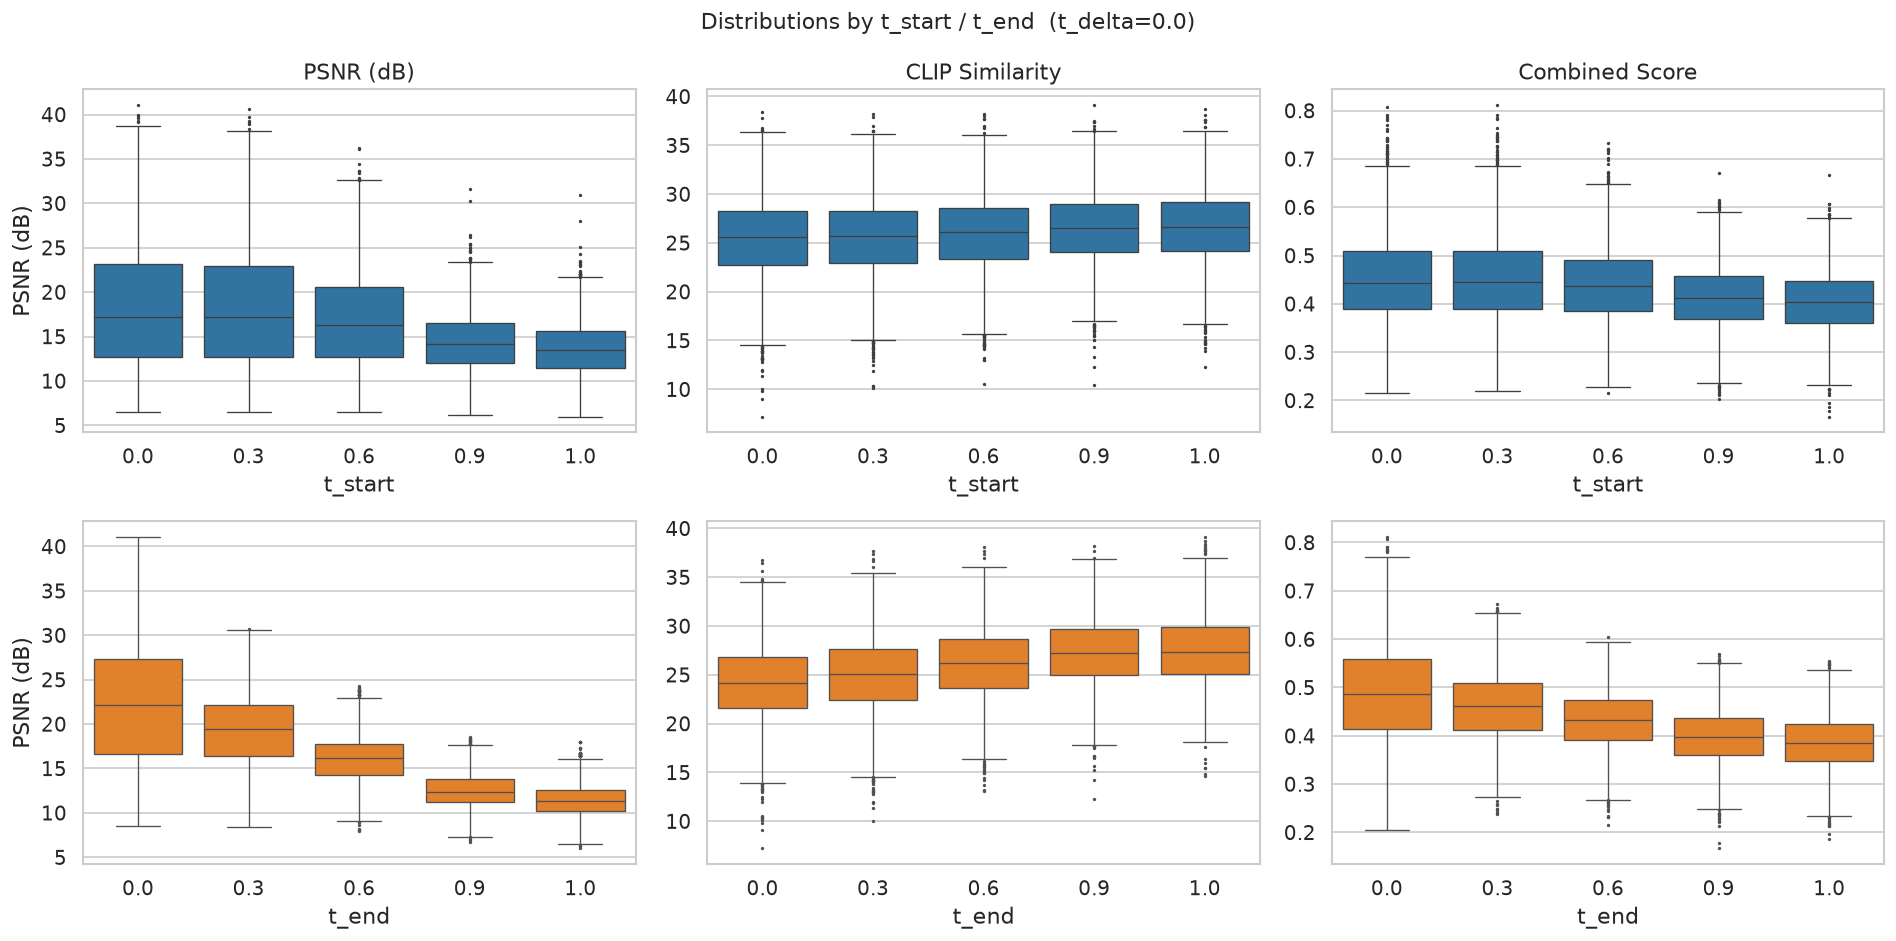

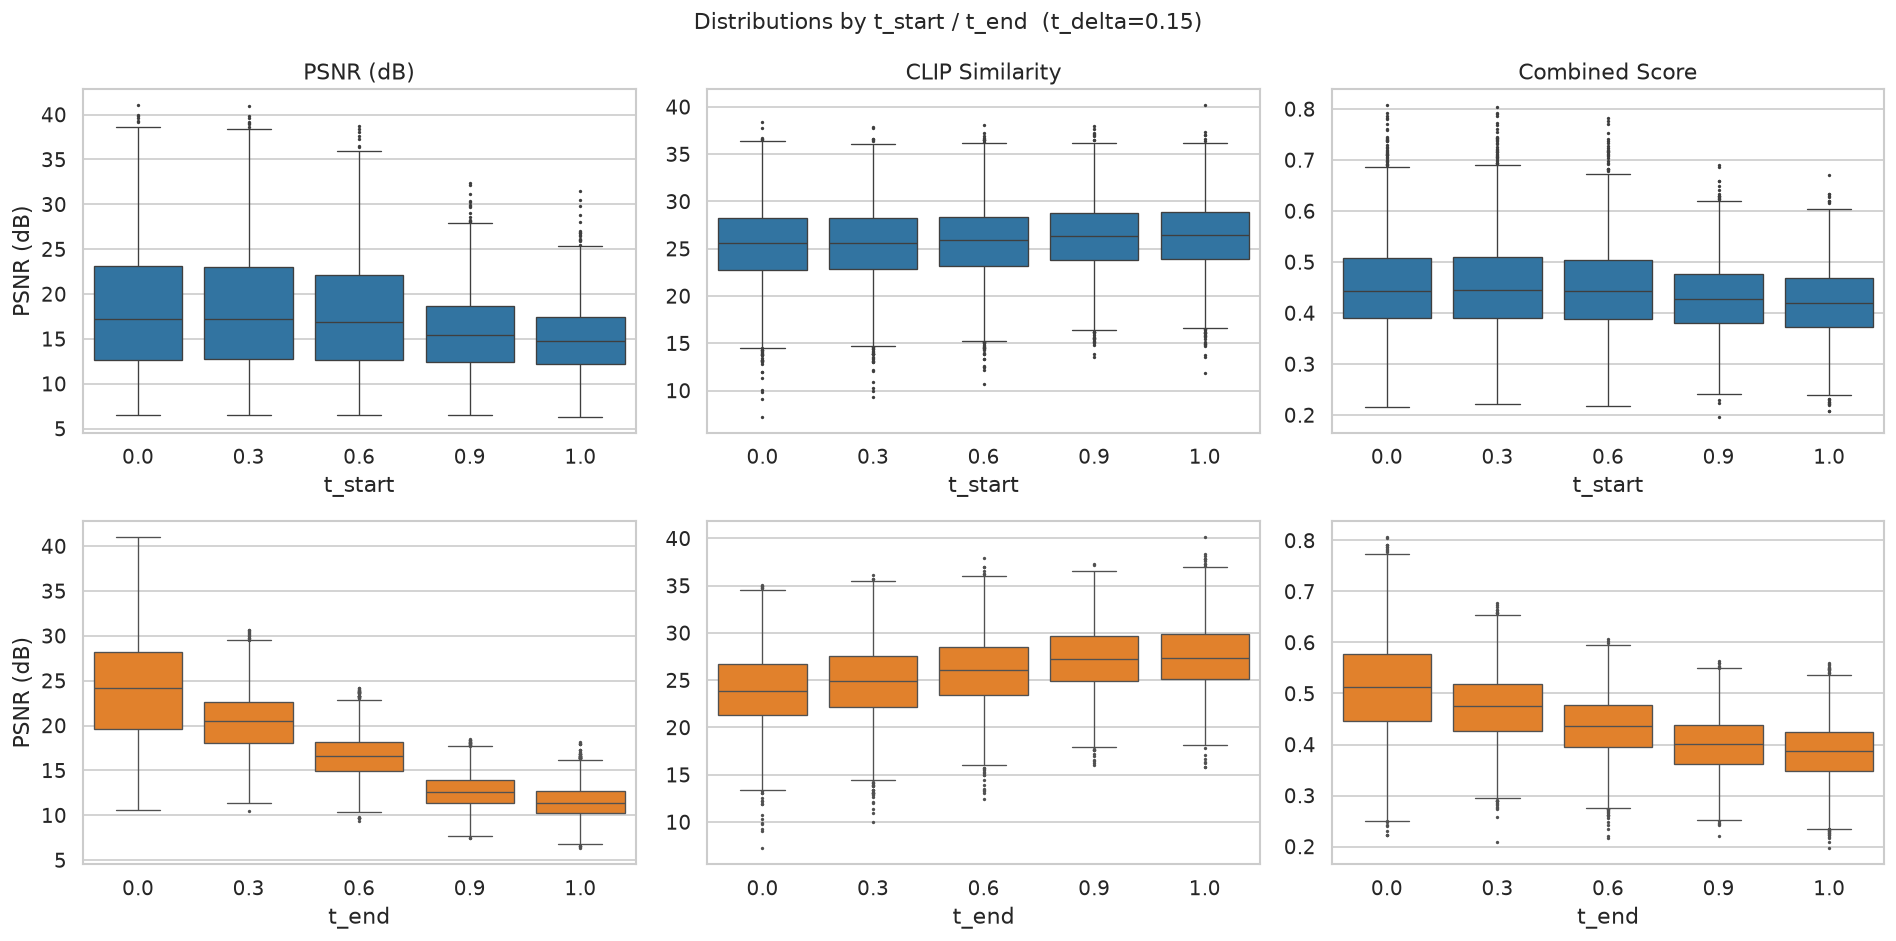

In [6]:
for td in t_delta_vals:
    sub = df[df["t_delta"] == td]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="col")
    for col_idx, m in enumerate(METRICS):
        for row_idx, param in enumerate(["t_start", "t_end"]):
            ax = axes[row_idx, col_idx]
            order = [str(v) for v in sorted(sub[param].cat.categories)]
            sns.boxplot(
                data=sub, x=param, y=m, order=order,
                ax=ax, color=colors[param], fliersize=1, linewidth=0.8,
            )
            ax.set_xlabel(param)
            ax.set_ylabel(METRIC_LABELS[m] if col_idx == 0 else "")
            ax.set_title(f"{METRIC_LABELS[m]}" if row_idx == 0 else "")
    fig.suptitle(f"Distributions by t_start / t_end  (t_delta={td})", fontsize=13)
    plt.tight_layout()
    plt.show()

### 4  Joint Effect: `t_start` × `t_end` Heatmaps

Each cell shows the mean metric value across the 700 samples at that `(t_start, t_end)` setting.
We separate the two `t_delta` values to compare their landscapes.

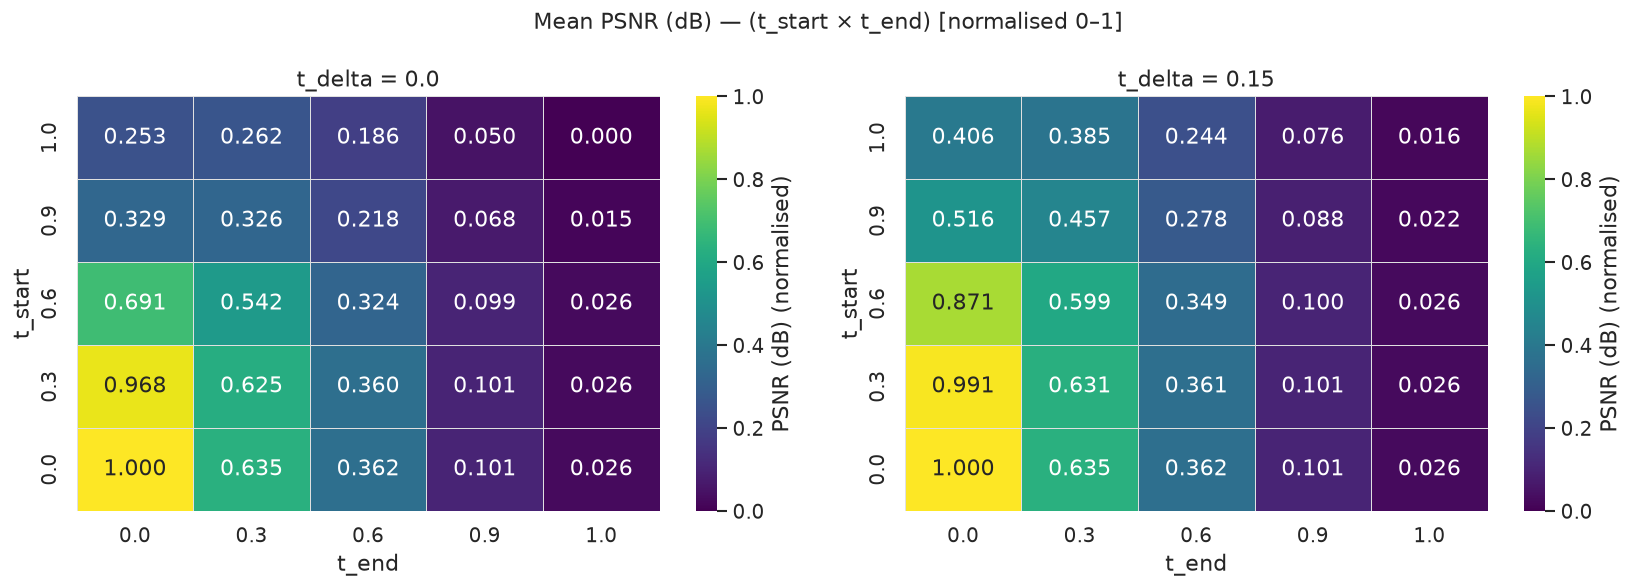

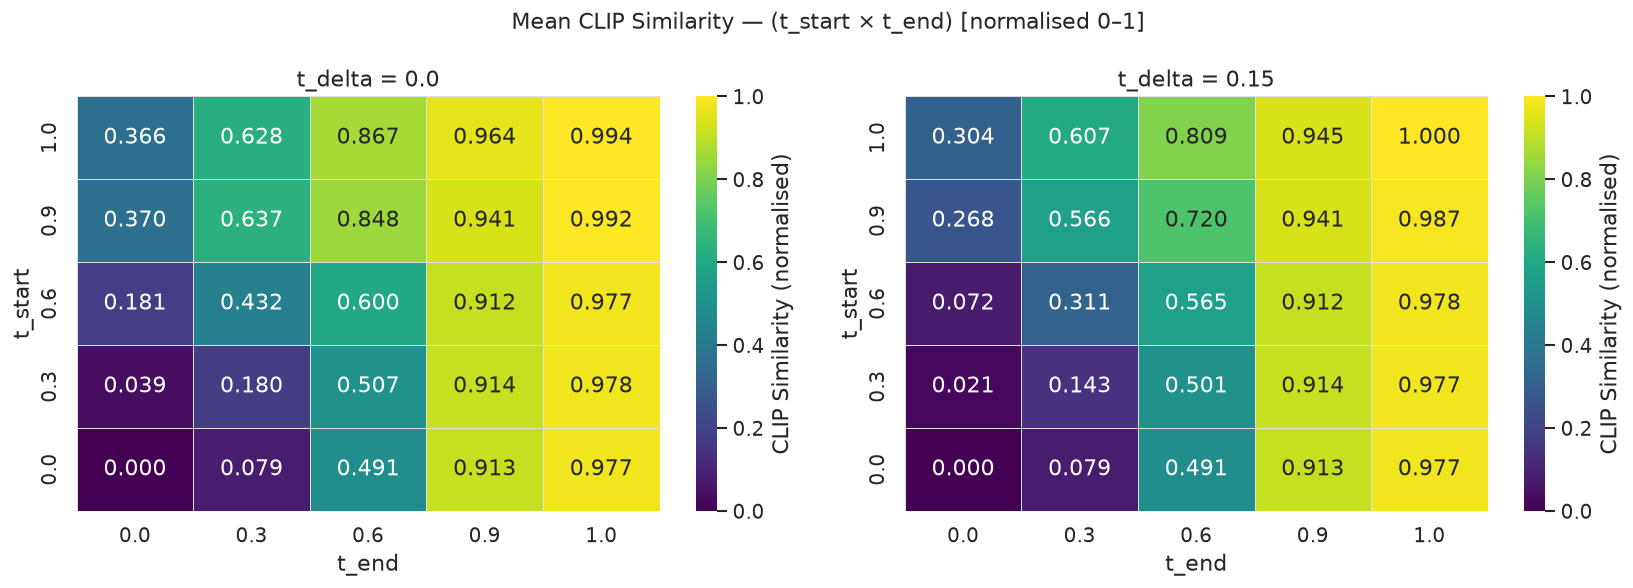

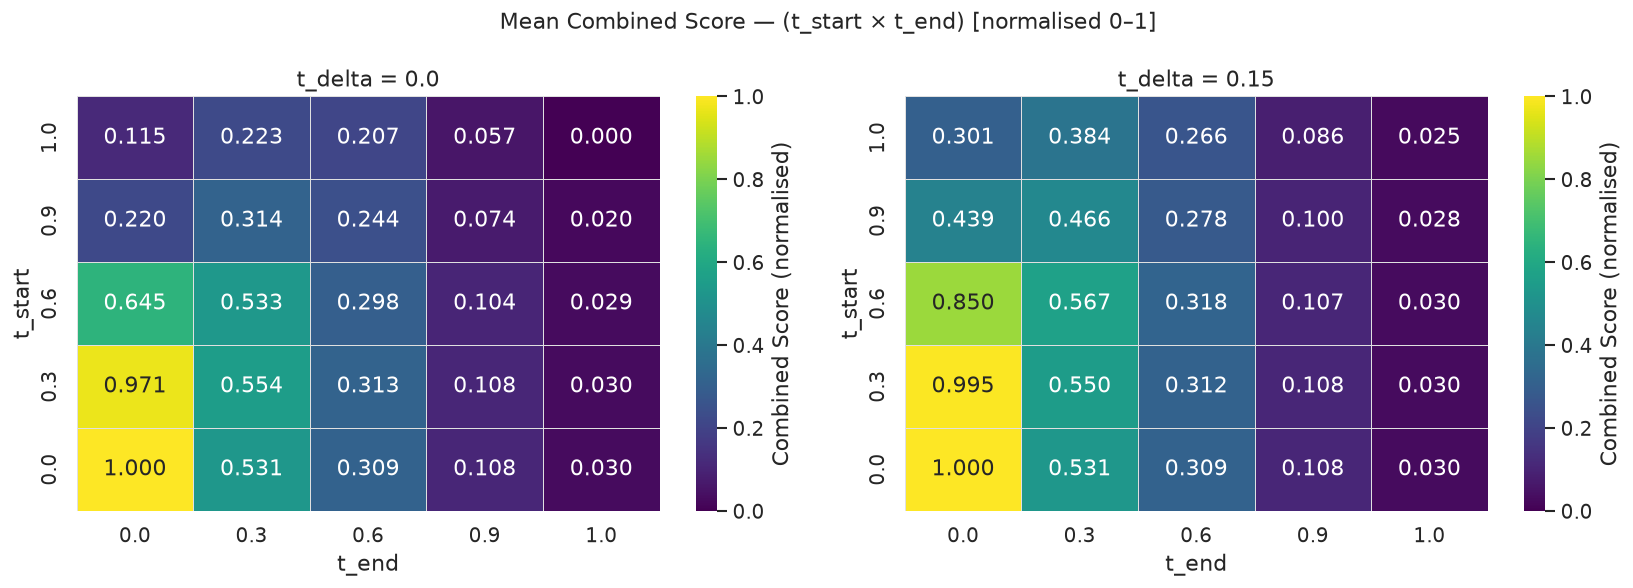

In [15]:
for m in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Build both pivots first so we can normalise across both t_delta panels
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for ax, td in zip(axes, t_delta_vals):
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)
        sns.heatmap(
            norm_pivot, ax=ax, annot=True, fmt=".3f",
            cmap="viridis", vmin=0, vmax=1,
            linewidths=0.4, linecolor="#e0e0e0",
            cbar_kws={"label": f"{METRIC_LABELS[m]} (normalised)"},
        )
        ax.set_title(f"t_delta = {td}")
        ax.set_xlabel("t_end")
        ax.set_ylabel("t_start")
        ax.invert_yaxis()
    fig.suptitle(f"Mean {METRIC_LABELS[m]} — (t_start × t_end) [normalised 0–1]", fontsize=13)
    plt.tight_layout()
    plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1093374/1391303133.py:46: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f"{METRIC_LABELS[m]} with $\delta$={td:.2f}")


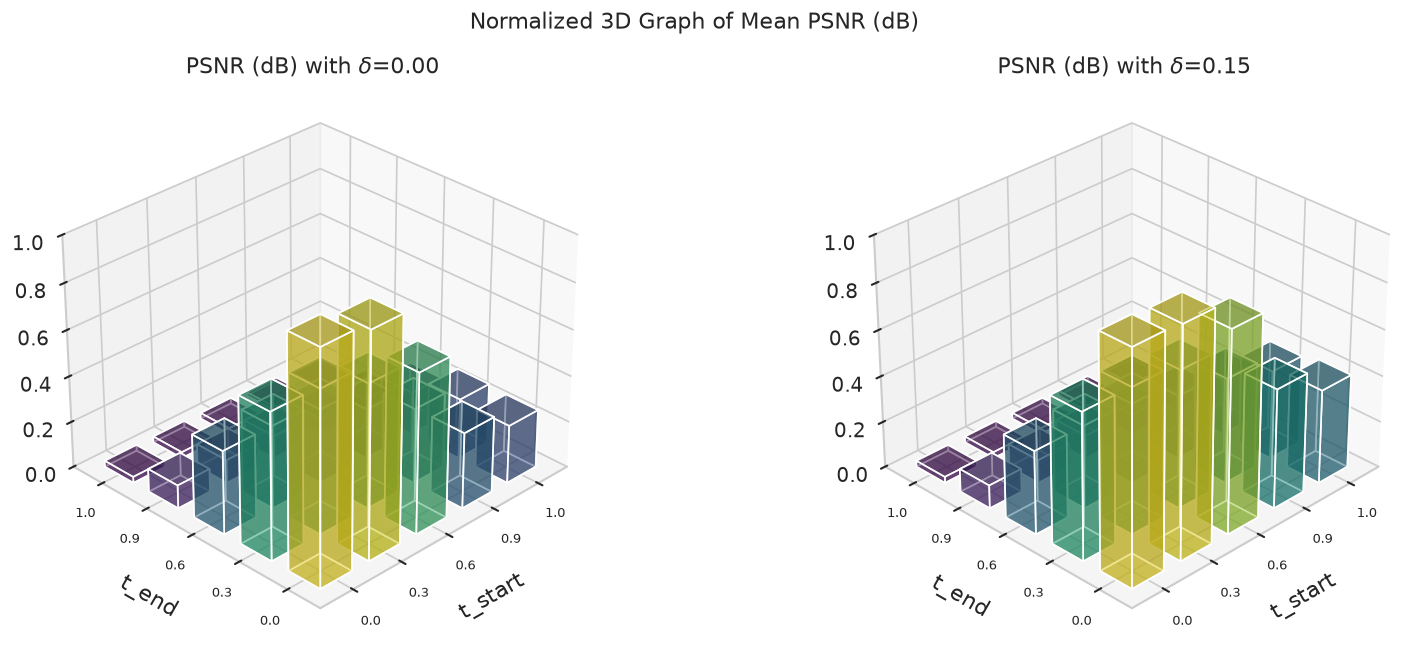

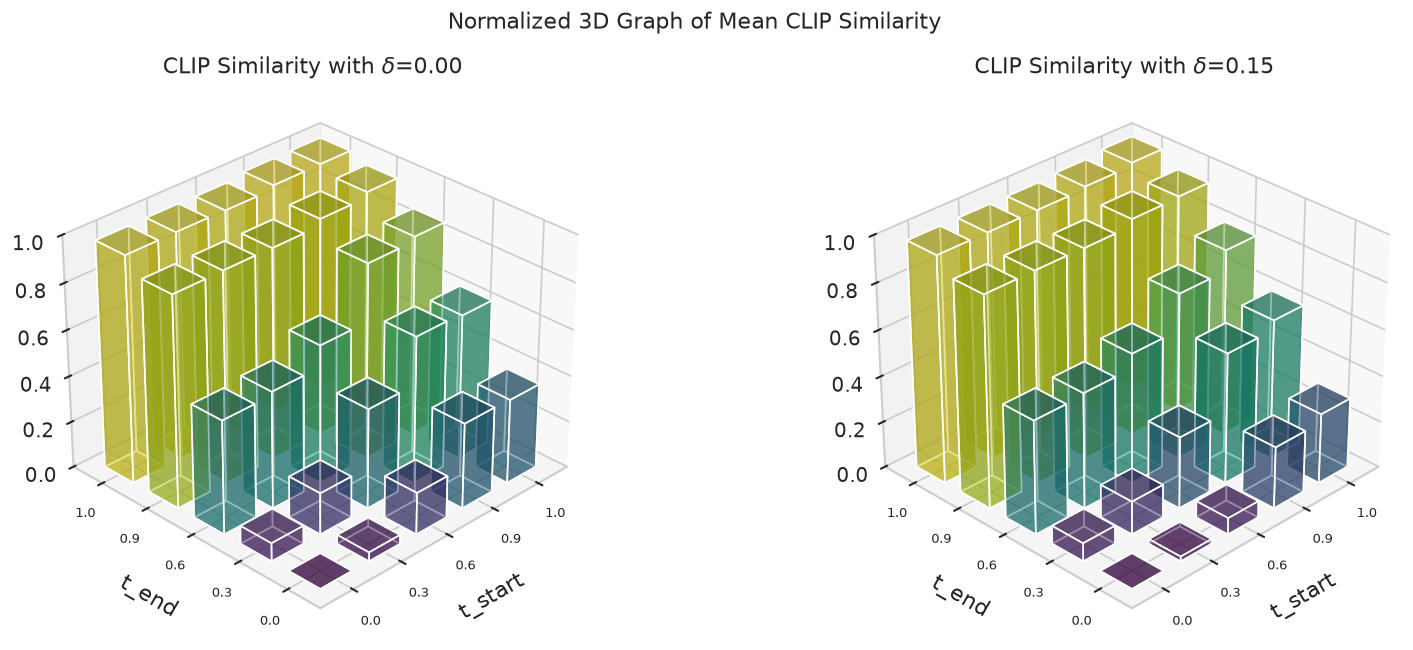

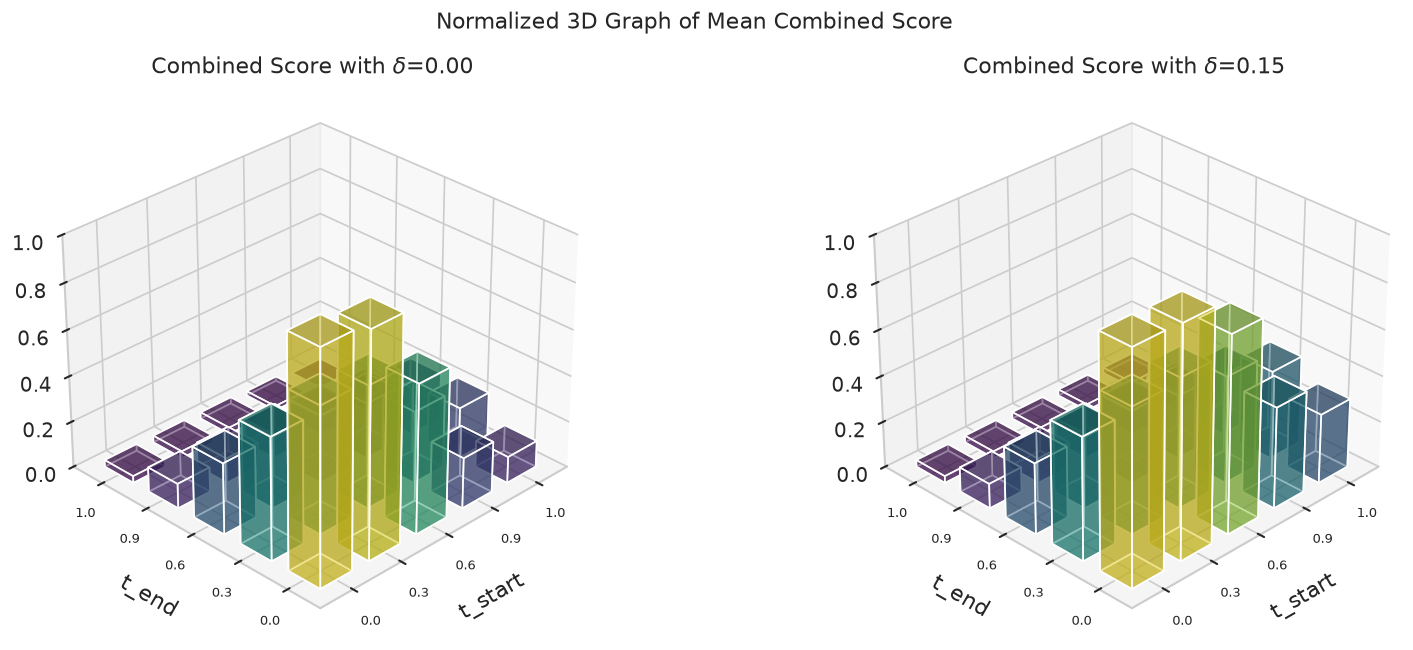

In [31]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

for m in METRICS:
    fig = plt.figure(figsize=(16, 6))

    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for i, td in enumerate(t_delta_vals):
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)

        xs = norm_pivot.index.values    # t_start
        ys = norm_pivot.columns.values  # t_end
        n_x, n_y = len(xs), len(ys)

        xpos = np.repeat(np.arange(n_x), n_y)
        ypos = np.tile(np.arange(n_y), n_x)
        zpos = np.zeros(n_x * n_y)
        dz   = norm_pivot.values.ravel()

        bar_colors = plt.cm.viridis(dz)
        ax.bar3d(xpos, ypos, zpos, dx=0.65, dy=0.65, dz=dz,
                 color=bar_colors, shade=True, alpha=0.50)

        ax.set_xticks(np.arange(n_x) + 0.325)
        ax.set_xticklabels([f"{v:.1f}" for v in xs], fontsize=8)
        ax.set_yticks(np.arange(n_y) + 0.325)
        ax.set_yticklabels([f"{v:.1f}" for v in ys], fontsize=8)
        ax.set_xlabel("t_start", labelpad=8)
        ax.set_ylabel("t_end",   labelpad=8)
        # ax.set_zlabel(f"Normalised {METRIC_LABELS[m]}", labelpad=8)
        ax.set_zlim(0, 1)
        ax.set_title(f"{METRIC_LABELS[m]} with $\delta$={td:.2f}")
        ax.view_init(elev=30, azim=225)  # isometric-style viewpoint

    mappable = plt.cm.ScalarMappable(cmap="viridis",
                                     norm=plt.Normalize(vmin=0, vmax=1))
    mappable.set_array([])
    fig.suptitle(f"Normalized 3D Graph of Mean {METRIC_LABELS[m]}",
                 fontsize=13)
    plt.show()


### 5  Interaction: Does `t_delta` Change the Landscape?

Plot the *difference* between the t_delta=0.15 heatmap and the t_delta=0.0 heatmap for
each metric.  Positive values (warm colours) mean t_delta=0.15 is better at that cell.

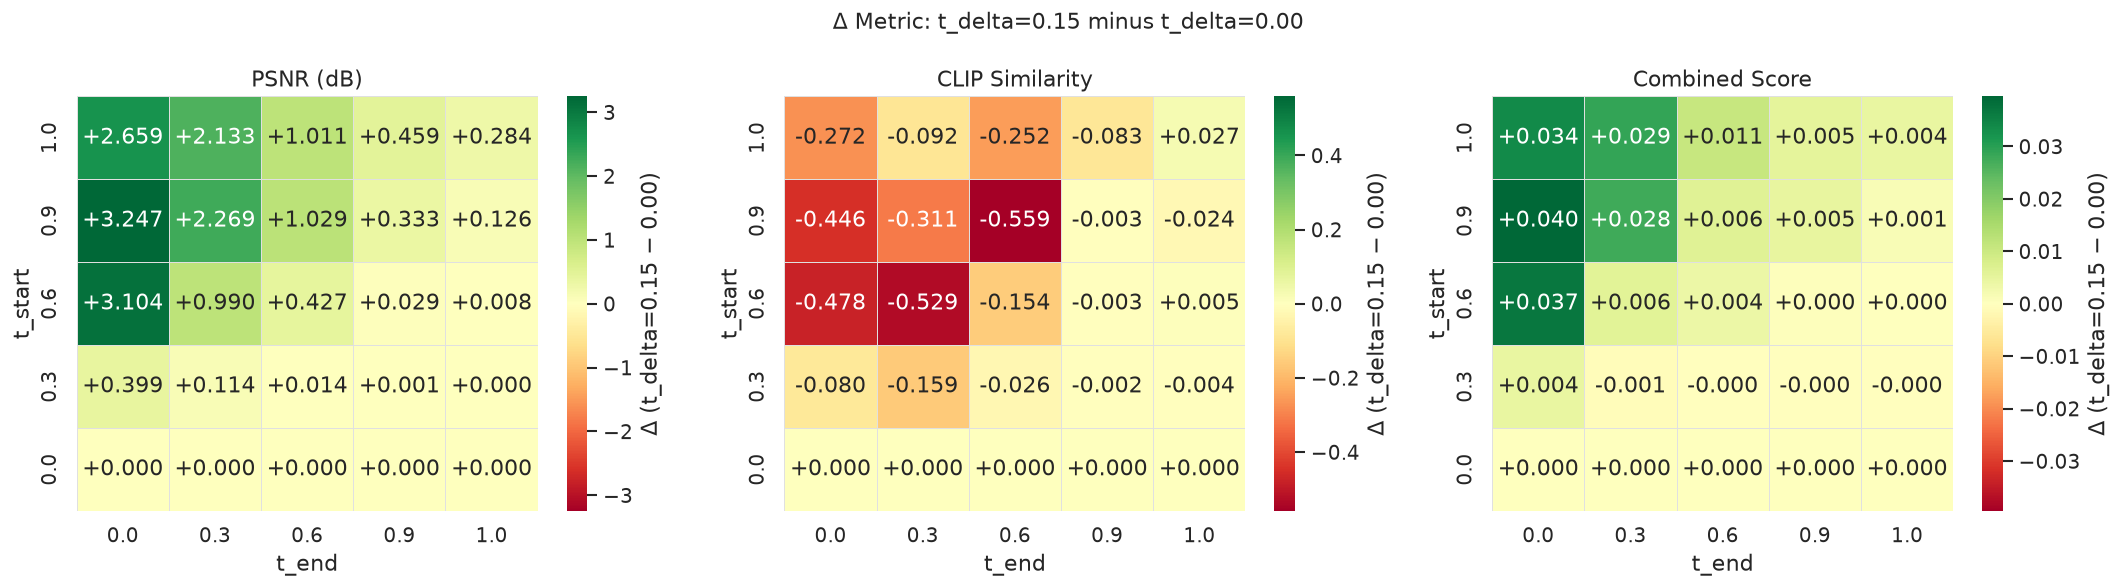

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, METRICS):
    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivots[td] = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean().unstack("t_end")
        )
    diff = pivots[0.15] - pivots[0.0]
    diff.index   = diff.index.astype(float)
    diff.columns = diff.columns.astype(float)
    lim = np.abs(diff.values).max()
    sns.heatmap(
        diff, ax=ax, annot=True, fmt="+.3f",
        cmap="RdYlGn", center=0, vmin=-lim, vmax=lim,
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": "Δ (t_delta=0.15 − 0.00)"},
    )
    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")
    ax.invert_yaxis()
fig.suptitle("Δ Metric: t_delta=0.15 minus t_delta=0.00", fontsize=13)
plt.tight_layout()
plt.show()

### 6  Metric Correlations

PSNR and CLIP similarity are independent signals; the combined score is their normalised
average.  A pairplot reveals how correlated they are in practice.

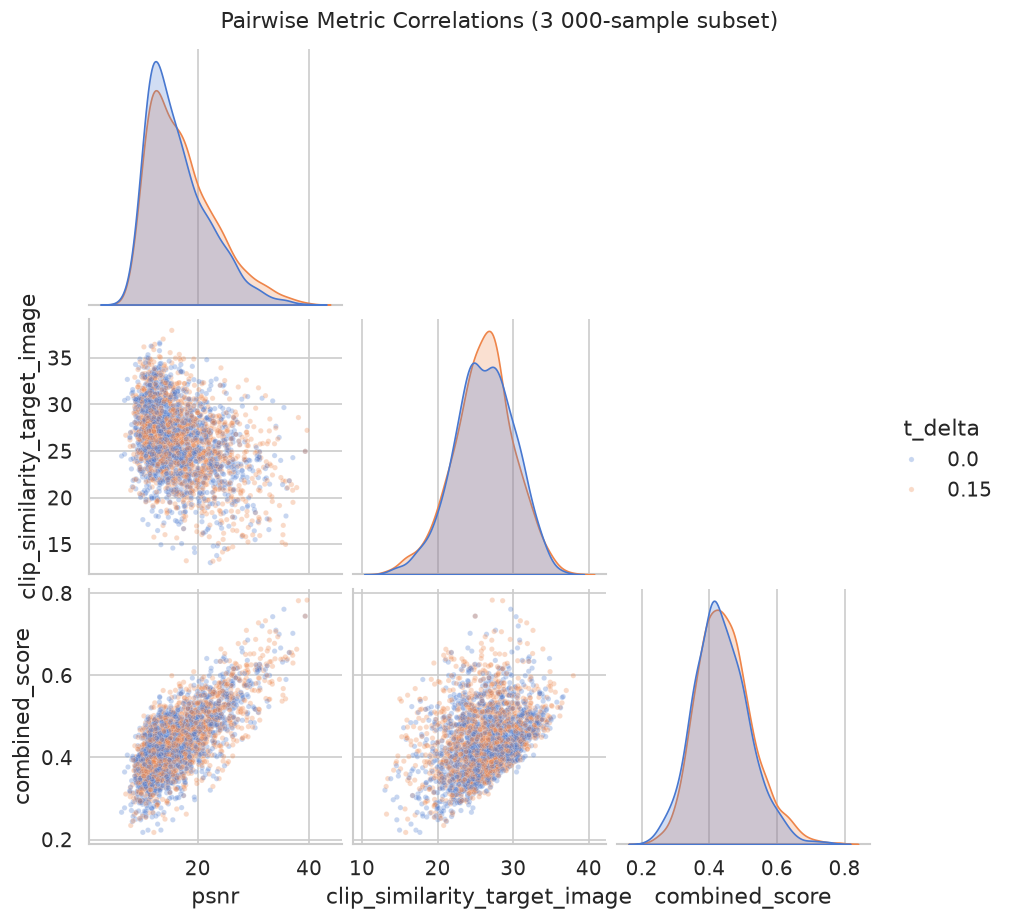

Pearson correlation matrix:


,psnr,clip_similarity_target_image,combined_score
psnr,1.000,-0.361,0.725
clip_similarity_target_image,-0.361,1.000,0.381
combined_score,0.725,0.381,1.000


In [9]:
sample = df.sample(n=3000, random_state=42)
g = sns.pairplot(
    sample[METRICS + ["t_delta"]],
    hue="t_delta",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    corner=True,
)
g.fig.suptitle("Pairwise Metric Correlations (3 000-sample subset)", y=1.02, fontsize=13)
plt.show()

print("Pearson correlation matrix:")
df[METRICS].corr().round(3)

### 7  Best Parameter Settings

For each metric we rank every `(t_start, t_end, t_delta)` triple by its **mean** value and
report the top-5.  We also report the 90th-percentile mean to favour settings that are
reliably good, not just occasionally high.

> **Note:** The training pipeline filters to `t_delta == 0.0` before selecting the best
> row per sample, so the analysis below includes a dedicated view of the `t_delta == 0.0`
> landscape.

In [10]:
stats = (
    df.groupby(["t_start", "t_end", "t_delta"], observed=True)[METRICS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

print("=== Top-5 by mean combined_score (all t_delta) ===")
display(
    stats.nlargest(5, "combined_score_mean")[
        ["t_start", "t_end", "t_delta",
         "combined_score_mean", "combined_score_std",
         "psnr_mean", "clip_similarity_target_image_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean PSNR (all t_delta) ===")
display(
    stats.nlargest(5, "psnr_mean")[
        ["t_start", "t_end", "t_delta",
         "psnr_mean", "psnr_std", "combined_score_mean"]
    ].round(4)
)

print("\n=== Top-5 by mean CLIP similarity (all t_delta) ===")
display(
    stats.nlargest(5, "clip_similarity_target_image_mean")[
        ["t_start", "t_end", "t_delta",
         "clip_similarity_target_image_mean",
         "clip_similarity_target_image_std", "combined_score_mean"]
    ].round(4)
)

=== Top-5 by mean combined_score (all t_delta) ===


,t_start,t_end,t_delta,combined_score_mean,combined_score_std,psnr_mean,clip_similarity_target_image_mean
0,0.0,0.0,0.00,0.5630,0.0806,28.3991,23.2692
1,0.0,0.0,0.15,0.5630,0.0806,28.3991,23.2692
11,0.3,0.0,0.15,0.5621,0.0799,28.2437,23.3588
10,0.3,0.0,0.00,0.5576,0.0797,27.8452,23.4385
21,0.6,0.0,0.15,0.5358,0.0806,26.1595,23.5811



=== Top-5 by mean PSNR (all t_delta) ===


,t_start,t_end,t_delta,psnr_mean,psnr_std,combined_score_mean
0,0.0,0.0,0.00,28.3991,4.1920,0.5630
1,0.0,0.0,0.15,28.3991,4.1920,0.5630
11,0.3,0.0,0.15,28.2437,4.1318,0.5621
10,0.3,0.0,0.00,27.8452,4.0399,0.5576
21,0.6,0.0,0.15,26.1595,3.8139,0.5358



=== Top-5 by mean CLIP similarity (all t_delta) ===


,t_start,t_end,t_delta,clip_similarity_target_image_mean,clip_similarity_target_image_std,combined_score_mean
49,1.0,1.0,0.15,27.6308,3.5853,0.3864
48,1.0,1.0,0.00,27.6042,3.5631,0.3820
38,0.9,1.0,0.00,27.5979,3.5724,0.3855
39,0.9,1.0,0.15,27.5741,3.5293,0.3870
18,0.3,1.0,0.00,27.5367,3.5128,0.3874


### 7.1  Best Settings at `t_delta == 0.0`

The training pipeline uses only the `t_delta == 0` slice, so the classifier needs to
predict the best `(t_start, t_end)` within that slice.

In [11]:
stats0 = (
    df[df["t_delta"] == 0.0]
    .groupby(["t_start", "t_end"], observed=True)[METRICS]
    .agg(["mean", "std", lambda x: x.quantile(0.9)])
)
stats0.columns = ["_".join(c) for c in stats0.columns]
stats0 = stats0.reset_index()

for m in METRICS:
    col = f"{m}_mean"
    top = stats0.nlargest(5, col).reset_index(drop=True)
    top.index += 1
    print(f"\n=== Top-5 (t_delta=0) by mean {METRIC_LABELS[m]} ===")
    display(top[["t_start", "t_end", col, f"{m}_std"]].round(4))


=== Top-5 (t_delta=0) by mean PSNR (dB) ===


,t_start,t_end,psnr_mean,psnr_std
1,0.0,0.0,28.3991,4.1920
2,0.3,0.0,27.8452,4.0399
3,0.6,0.0,23.0557,3.7636
4,0.0,0.3,22.0798,2.7996
5,0.3,0.3,21.9047,2.7915



=== Top-5 (t_delta=0) by mean CLIP Similarity ===


,t_start,t_end,clip_similarity_target_image_mean,clip_similarity_target_image_std
1,1.0,1.0,27.6042,3.5631
2,0.9,1.0,27.5979,3.5724
3,0.3,1.0,27.5367,3.5128
4,0.0,1.0,27.5310,3.5218
5,0.6,1.0,27.5293,3.5019



=== Top-5 (t_delta=0) by mean Combined Score ===


,t_start,t_end,combined_score_mean,combined_score_std
1,0.0,0.0,0.5630,0.0806
2,0.3,0.0,0.5576,0.0797
3,0.6,0.0,0.4988,0.0800
4,0.3,0.3,0.4823,0.0677
5,0.6,0.3,0.4784,0.0641


### 7.2  Visual Summary: Ranked Cells (t_delta = 0)

Each heatmap is re-drawn with the **top-3 cells** annotated with their rank.

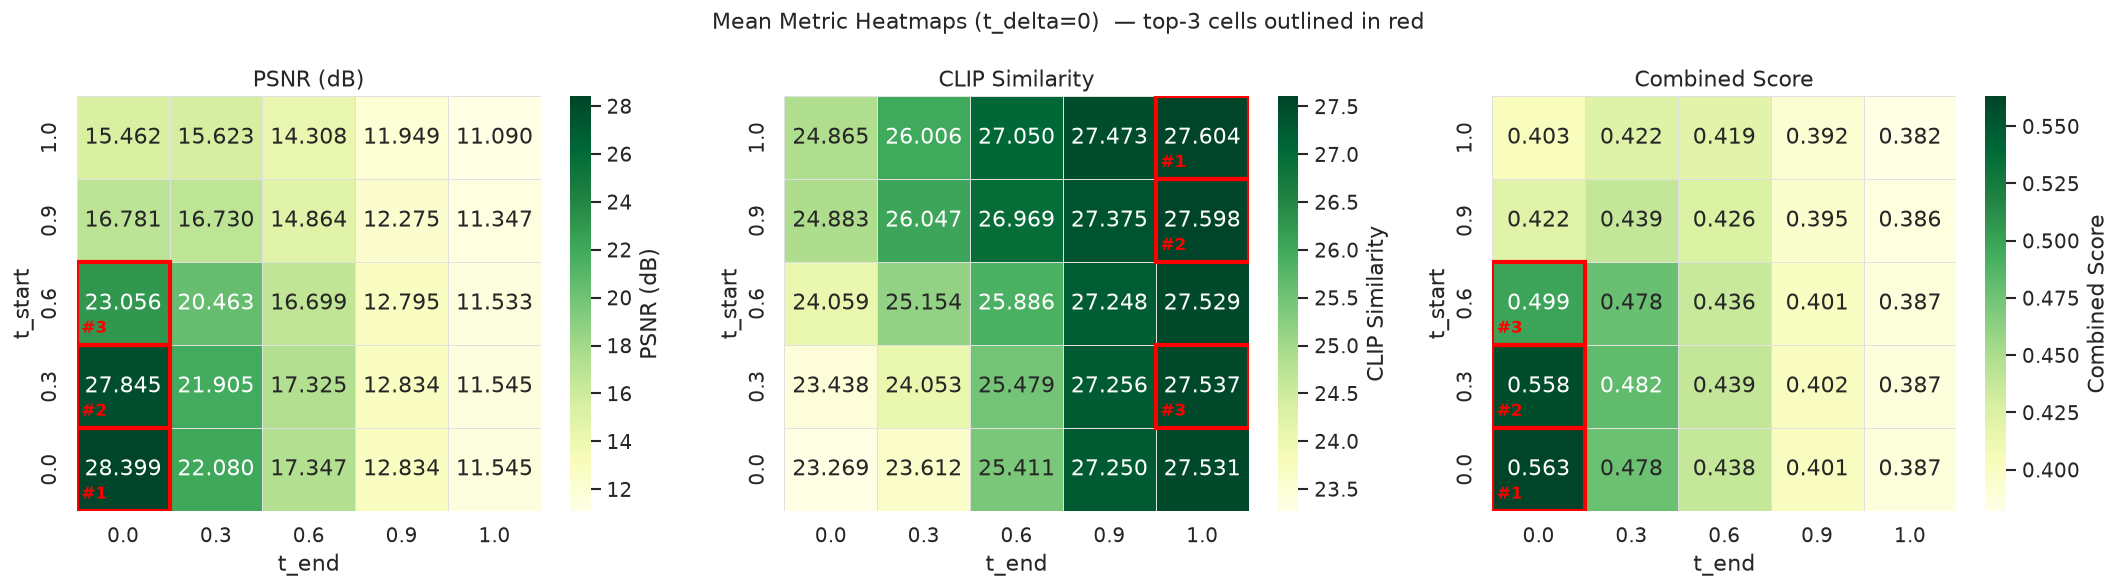

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sub0 = df[df["t_delta"] == 0.0]

for ax, m in zip(axes, METRICS):
    pivot = (
        sub0.groupby(["t_start", "t_end"], observed=True)[m]
        .mean().unstack("t_end")
    )
    pivot.index   = pivot.index.astype(float)
    pivot.columns = pivot.columns.astype(float)

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f",
        cmap="YlGn",
        linewidths=0.4, linecolor="#e0e0e0",
        cbar_kws={"label": METRIC_LABELS[m]},
    )
    ax.invert_yaxis()

    # Annotate top-3 cells with rank badges
    flat = pivot.stack().sort_values(ascending=False)
    rows_list = list(pivot.index)
    cols_list = list(pivot.columns)
    for rank, (idx, _) in enumerate(flat.head(3).items(), start=1):
        r, c = idx
        ri = rows_list.index(r)
        ci = cols_list.index(c)
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor="red", lw=2.5))
        ax.text(ci + 0.05, ri + 0.15, f"#{rank}", color="red",
                fontsize=10, fontweight="bold")

    ax.set_title(METRIC_LABELS[m])
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")

fig.suptitle("Mean Metric Heatmaps (t_delta=0)  — top-3 cells outlined in red", fontsize=13)
plt.tight_layout()
plt.show()

### 8  Summary: Best Parameters per Metric

The table below consolidates the single best `(t_start, t_end)` for each metric
within the `t_delta == 0` slice (which is what the classifier is trained to predict).

In [13]:
rows = []
for m in METRICS:
    col = f"{m}_mean"
    best = stats0.loc[stats0[col].idxmax()]
    rows.append({
        "Metric": METRIC_LABELS[m],
        "Best t_start": float(best["t_start"]),
        "Best t_end":   float(best["t_end"]),
        "Mean value":   round(best[col], 4),
        "Std dev":      round(best[f"{m}_std"], 4),
    })

summary = pd.DataFrame(rows).set_index("Metric")
display(summary)

,Best t_start,Best t_end,Mean value,Std dev
Metric,,,,
PSNR (dB),0.0,0.0,28.3991,4.1920
CLIP Similarity,1.0,1.0,27.6042,3.5631
Combined Score,0.0,0.0,0.5630,0.0806


### Key Observations

Run the cells above and the summary table will populate.  Based on typical diffusion-edit
results we expect to see:

* **PSNR** tends to peak at **low `t_start` values** (the edit starts very early in the
  denoising trajectory, so the reconstructed image stays close to the original in
  pixel space).
* **CLIP similarity** benefits from a **higher `t_end`** (more denoising steps are spent
  driving the output toward the target prompt's semantic content).
* **Combined score** sits at the Pareto frontier between the two signals above, typically
  favouring a mid-range `t_start` paired with a high `t_end`.
* **`t_delta = 0.15`** generally shifts both PSNR and CLIP similarity relative to `t_delta = 0.0`;
  the signed-difference heatmap in §5 reveals whether the gap is uniform or
  concentrated in particular `(t_start, t_end)` regions.

## Appendix: Full Ranking Table (t_delta = 0)

All 25 `(t_start, t_end)` cells sorted by `combined_score`.

In [14]:
full = stats0.sort_values("combined_score_mean", ascending=False).reset_index(drop=True)
full.index += 1
display(
    full[[
        "t_start", "t_end",
        "combined_score_mean", "combined_score_std",
        "psnr_mean", "psnr_std",
        "clip_similarity_target_image_mean", "clip_similarity_target_image_std",
    ]].rename(columns={
        "combined_score_mean": "combined (mean)",
        "combined_score_std":  "combined (std)",
        "psnr_mean": "PSNR (mean)",
        "psnr_std":  "PSNR (std)",
        "clip_similarity_target_image_mean": "CLIP (mean)",
        "clip_similarity_target_image_std":  "CLIP (std)",
    }).round(4)
)

,t_start,t_end,combined (mean),combined (std),PSNR (mean),PSNR (std),CLIP (mean),CLIP (std)
1,0.0,0.0,0.5630,0.0806,28.3991,4.1920,23.2692,4.0597
2,0.3,0.0,0.5576,0.0797,27.8452,4.0399,23.4385,3.9762
3,0.6,0.0,0.4988,0.0800,23.0557,3.7636,24.0595,3.9012
4,0.3,0.3,0.4823,0.0677,21.9047,2.7915,24.0526,3.9908
5,0.6,0.3,0.4784,0.0641,20.4629,2.8541,25.1541,3.8888
6,0.0,0.3,0.4781,0.0690,22.0798,2.7996,23.6119,4.0829
7,0.9,0.3,0.4388,0.0646,16.7297,2.6162,26.0475,3.6440
8,0.3,0.6,0.4386,0.0595,17.3255,2.2187,25.4789,3.7750
9,0.0,0.6,0.4379,0.0594,17.3472,2.2183,25.4109,3.7455
10,0.6,0.6,0.4359,0.0603,16.6986,2.2600,25.8857,3.7716
